In [ ]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

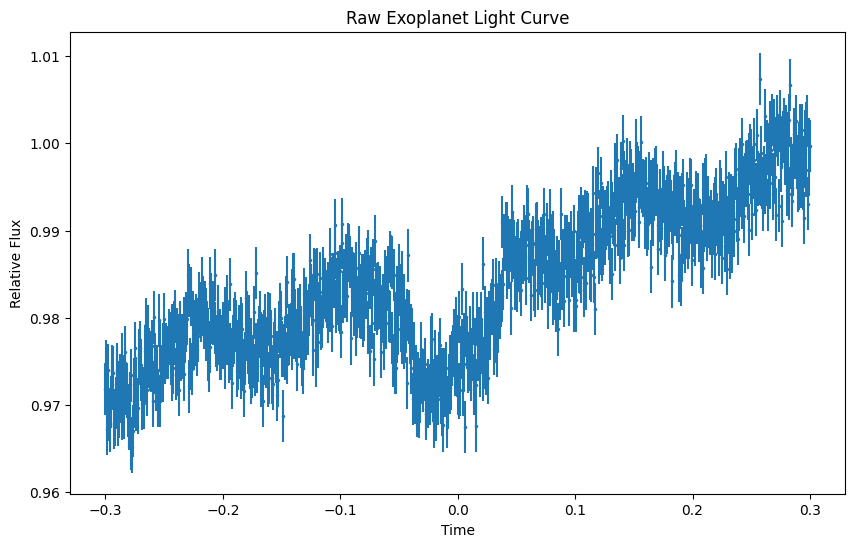

In [ ]:
Lightcurve_table = Table.read("Planet_Lightcurve.fits", format="fits")

# X axis and Y axis of data
x = np.array(Lightcurve_table.columns[0])
y = np.array(Lightcurve_table.columns[1])

# uncertainty
y_err = np.full(len(y), 0.003)

# Plot raw data
plt.figure(figsize=(10,6))
plt.errorbar(x, y, yerr=y_err, fmt='.', markersize=3)

plt.xlabel("Time")
plt.ylabel("Relative Flux")
plt.title("Raw Exoplanet Light Curve")

plt.savefig("raw_lightcurve.pdf")
plt.show()


In [ ]:
# ==========================================
# Define artifact model
# Linear trend + sinusoidal oscillation
# ==========================================

def artifact_model(x, m, b, A, omega, phi):
    return m*x + b + A*np.sin(omega*x + phi)


In [ ]:
# ==========================================
# Initial parameter guesses
# ==========================================

m_guess = 0
b_guess = np.mean(y)
A_guess = 0.01
omega_guess = 2*np.pi
phi_guess = 0

guess = [
    m_guess,
    b_guess,
    A_guess,
    omega_guess,
    phi_guess
]

In [ ]:
# ==========================================
# Fit model
# ==========================================

params, cov = curve_fit(
    artifact_model,
    x,
    y,
    sigma=y_err,
    p0=guess,
    absolute_sigma=True
)

errors = np.sqrt(np.diag(cov))


In [ ]:
# ==========================================
# Print fit results
# ==========================================

names = ["m", "b", "A", "omega", "phi"]

print("Best Fit Parameters:")
print()

for name, value, error in zip(names, params, errors):
    print(f"{name} = {value:.6f} ± {error:.6f}")


Best Fit Parameters:

m = 0.040695 ± 0.000554
b = 0.982983 ± 0.000100
A = 0.003511 ± 0.000143
omega = 15.948516 ± 0.213459
phi = -1.646452 ± 0.038331


In [ ]:
# ==========================================
# Create smooth fit curve
# ==========================================

x_fit = np.linspace(np.min(x), np.max(x), 1000)
y_fit = artifact_model(x_fit, *params)

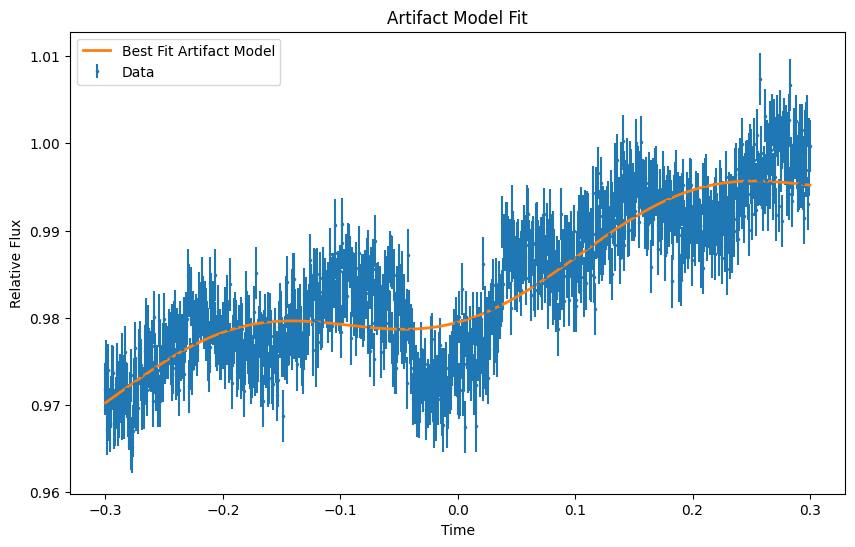

In [ ]:
# ==========================================
# Plot fit and data together
# ==========================================

plt.figure(figsize=(10,6))

plt.errorbar(
    x,
    y,
    yerr=y_err,
    fmt='.',
    markersize=3,
    label='Data'
)

plt.plot(
    x_fit,
    y_fit,
    linewidth=2,
    label='Best Fit Artifact Model'
)

plt.xlabel("Time")
plt.ylabel("Relative Flux")
plt.title("Artifact Model Fit")

plt.legend()

plt.savefig("artifact_fit.pdf")
plt.show()


In [ ]:
# ==========================================
# Remove artifacts
# ==========================================

artifact = artifact_model(x, *params)

corrected_flux = y / artifact



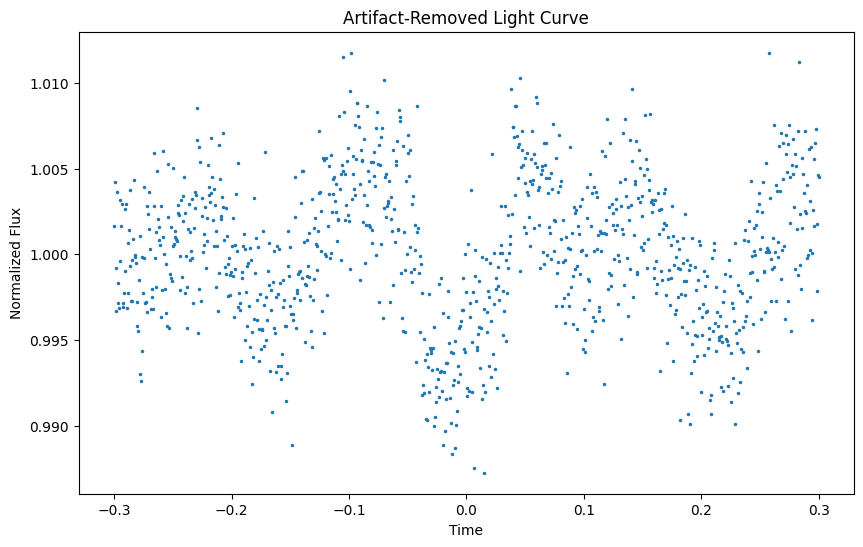

In [ ]:
# ==========================================
# Plot corrected light curve
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(
    x,
    corrected_flux,
    '.',
    markersize=3
)

plt.xlabel("Time")
plt.ylabel("Normalized Flux")
plt.title("Artifact-Removed Light Curve")

plt.savefig("corrected_lightcurve.pdf")
plt.show()

In [ ]:
# Step 3
star_radius = 1
cleaned_dataset = corrected_flux

baseline = np.median(cleaned_dataset)
depth = baseline - np.min(cleaned_dataset)

mask = cleaned_dataset < (baseline - depth/2)
duration = x[mask].max() - x[mask].min()

planet_radius = star_radius*np.sqrt(depth)





print(f"Transit Depth: {depth}")
print(f"Transit Duration: {duration} Days")
print(f"Radius: {planet_radius}")

plt.figure()
plt.plot(cleaned_dataset, planet_radius, ".", marker_size=2)
plt.xlabel("Normalized Flux")
plt.ylabel("Planet Radius")
plt.show()

In [ ]:
# Step 4

error_margin = 0.003






In [ ]:
# Step 5

# Our 4th member never responded to our outreach :(